In [1]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Upload final sarcasm dataset

from google.colab import files

uploaded = files.upload()

Saving final_sarcasm_dataset.csv to final_sarcasm_dataset.csv


In [3]:
# Load final sarcasm dataset

import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(
    io.BytesIO(uploaded[file_name])
)

print("Dataset loaded successfully!")
print("File name:", file_name)
print("Dataset shape:", df.shape)

Dataset loaded successfully!
File name: final_sarcasm_dataset.csv
Dataset shape: (5665, 5)


In [4]:
# Step 2: Validate the final sarcasm dataset

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDuplicate texts:",
      df['clean_tweet_v2'].duplicated().sum())

print("\nSarcasm label distribution:")
print(df['Label'].value_counts().sort_index())

print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (5665, 5)

Missing values:
id                0
Label             0
clean_tweet_v2    0
text_length       0
word_count        0
dtype: int64

Duplicate rows: 0

Duplicate texts: 0

Sarcasm label distribution:
Label
-1    3221
 1    2444
Name: count, dtype: int64

Columns:
['id', 'Label', 'clean_tweet_v2', 'text_length', 'word_count']


In [5]:
X = df['clean_tweet_v2']
y = df['Label']

In [6]:
# Step 3: Prepare X and y for Deep Learning

X = df['clean_tweet_v2']
y = df['Label']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 text samples:")
print(X.head())

print("\nFirst 5 labels:")
print(y.head())

X shape: (5665,)
y shape: (5665,)

First 5 text samples:
0                       मध्ये करत खरंच करत हेच कळत राव
1                                 अबे येड्या कळतो तुला
2              बरं झालं लिहिले आजच बावनकुळे असते तुमचे
3    किव्वा चे द्यावे नमो च्या नावाने आहेच विमानतळ ...
4    वी नापास नांगरगठ्ठ्या देशाचा पंतप्रधान होऊन बस...
Name: clean_tweet_v2, dtype: object

First 5 labels:
0   -1
1   -1
2   -1
3   -1
4   -1
Name: Label, dtype: int64


In [7]:
# Step 4: Encode sarcasm labels

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Label mapping:")

for label, encoded_value in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(label, "→", encoded_value)

print("\nFirst 10 encoded labels:")
print(y_encoded[:10])

Label mapping:
-1 → 0
1 → 1

First 10 encoded labels:
[0 0 0 0 0 0 0 1 0 0]


In [8]:
# Step 5: Train / Validation / Test Split

from sklearn.model_selection import train_test_split

# First split: 80% train+validation, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Second split: 90% training, 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.10,
    random_state=42,
    stratify=y_train_val
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 4078
Validation samples: 454
Testing samples: 1133


In [9]:
print("\nTraining distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTesting distribution:")
print(pd.Series(y_test).value_counts().sort_index())


Training distribution:
0    2319
1    1759
Name: count, dtype: int64

Validation distribution:
0    258
1    196
Name: count, dtype: int64

Testing distribution:
0    644
1    489
Name: count, dtype: int64


In [10]:
# Step 6: Tokenization

from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Tokenization completed successfully!")

print("\nVocabulary size:", len(tokenizer.word_index))

print("\nFirst training sequence:")
print(X_train_seq[0])

Tokenization completed successfully!

Vocabulary size: 13232

First training sequence:
[3, 108, 483, 4, 429, 1927, 283, 484]


In [11]:
# Step 7: Analyze sequence lengths

train_lengths = [len(seq) for seq in X_train_seq]

print("Sequence length statistics:")
print(pd.Series(train_lengths).describe())

Sequence length statistics:
count    4078.000000
mean        9.753065
std         6.890580
min         1.000000
25%         5.000000
50%         7.000000
75%        12.000000
max        43.000000
dtype: float64


In [12]:
# Check useful percentiles

for percentile in [90, 95, 99, 100]:
    print(
        f"{percentile}th percentile:",
        int(np.percentile(train_lengths, percentile))
    )

90th percentile: 19
95th percentile: 25
99th percentile: 33
100th percentile: 43


In [13]:
# Step 8: Pad sequences

from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 33

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print("Training padded shape:", X_train_pad.shape)
print("Validation padded shape:", X_val_pad.shape)
print("Testing padded shape:", X_test_pad.shape)

print("\nFirst padded training sequence:")
print(X_train_pad[0])

Training padded shape: (4078, 33)
Validation padded shape: (454, 33)
Testing padded shape: (1133, 33)

First padded training sequence:
[   3  108  483    4  429 1927  283  484    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0]


In [14]:
# Step 9: One-hot encode sarcasm labels

from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(
    y_train,
    num_classes=2
)

y_val_cat = to_categorical(
    y_val,
    num_classes=2
)

y_test_cat = to_categorical(
    y_test,
    num_classes=2
)

print("Training labels shape:", y_train_cat.shape)
print("Validation labels shape:", y_val_cat.shape)
print("Testing labels shape:", y_test_cat.shape)

print("\nFirst 5 training labels:")
print(y_train_cat[:5])

Training labels shape: (4078, 2)
Validation labels shape: (454, 2)
Testing labels shape: (1133, 2)

First 5 training labels:
[[0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [15]:
# Step 10: Common Deep Learning configuration

VOCAB_SIZE = 10000
MAX_LEN = 33
EMBEDDING_DIM = 128
NUM_CLASSES = 2

print("DL configuration:")
print("Vocabulary size :", VOCAB_SIZE)
print("Maximum length  :", MAX_LEN)
print("Embedding dim   :", EMBEDDING_DIM)
print("Number of classes:", NUM_CLASSES)

DL configuration:
Vocabulary size : 10000
Maximum length  : 33
Embedding dim   : 128
Number of classes: 2


In [16]:
# Step 11: Build RNN model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout

rnn_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    SimpleRNN(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 33, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,294,498 (4.94 MB)

 Trainable params: 1,294,498 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Step 12: Train RNN

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_rnn = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

rnn_history = rnn_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_rnn],
    verbose=1
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7989 - loss: 0.4607 - val_accuracy: 0.8326 - val_loss: 0.3871
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8987 - loss: 0.2681 - val_accuracy: 0.8040 - val_loss: 0.4728
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9627 - loss: 0.1158 - val_accuracy: 0.7996 - val_loss: 0.6292
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9865 - loss: 0.0497 - val_accuracy: 0.8150 - val_loss: 0.6674


In [20]:
# Step 13: Evaluate RNN on test data

rnn_test_loss, rnn_test_accuracy = rnn_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("RNN Test Loss:", round(rnn_test_loss, 4))
print("RNN Test Accuracy:", round(rnn_test_accuracy, 4))

RNN Test Loss: 0.3518
RNN Test Accuracy: 0.8526


In [21]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


In [22]:
# RNN predictions and detailed metrics

y_pred_rnn_prob = rnn_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_rnn = np.argmax(
    y_pred_rnn_prob,
    axis=1
)

rnn_accuracy = accuracy_score(
    y_test,
    y_pred_rnn
)

rnn_precision = precision_score(
    y_test,
    y_pred_rnn,
    average='weighted'
)

rnn_recall = recall_score(
    y_test,
    y_pred_rnn,
    average='weighted'
)

rnn_f1 = f1_score(
    y_test,
    y_pred_rnn,
    average='weighted'
)

print("\nRNN Results")
print("-----------")
print("Accuracy :", round(rnn_accuracy, 4))
print("Precision:", round(rnn_precision, 4))
print("Recall   :", round(rnn_recall, 4))
print("F1-score :", round(rnn_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rnn,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_rnn
    )
)


RNN Results
-----------
Accuracy : 0.8526
Precision: 0.8794
Recall   : 0.8526
F1-score : 0.8464

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.80      0.99      0.88       644
    Sarcastic       0.99      0.67      0.80       489

     accuracy                           0.85      1133
    macro avg       0.89      0.83      0.84      1133
 weighted avg       0.88      0.85      0.85      1133


Confusion Matrix:
[[640   4]
 [163 326]]


In [23]:
# Step 14: Store Sarcasm RNN results

dl_results = []

dl_results.append({
    'Model': 'RNN',
    'Accuracy': rnn_accuracy,
    'Precision': rnn_precision,
    'Recall': rnn_recall,
    'F1-Score': rnn_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.852604,0.879389,0.852604,0.846394


In [24]:
# Step 15: Build LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout
)

lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 33, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,554 (5.08 MB)

 Trainable params: 1,331,554 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Step 16: Train LSTM

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_lstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_lstm],
    verbose=1
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.6373 - loss: 0.6236 - val_accuracy: 0.8040 - val_loss: 0.4389
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7629 - loss: 0.4725 - val_accuracy: 0.5639 - val_loss: 0.6395
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7030 - loss: 0.5172 - val_accuracy: 0.6344 - val_loss: 0.6322
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8207 - loss: 0.4097 - val_accuracy: 0.7181 - val_loss: 0.5573


In [26]:
# Step 17: Evaluate LSTM on test data

lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("LSTM Test Loss:", round(lstm_test_loss, 4))
print("LSTM Test Accuracy:", round(lstm_test_accuracy, 4))

LSTM Test Loss: 0.3931
LSTM Test Accuracy: 0.8367


In [27]:
# LSTM predictions and detailed metrics

y_pred_lstm_prob = lstm_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_lstm = np.argmax(
    y_pred_lstm_prob,
    axis=1
)

lstm_accuracy = accuracy_score(
    y_test,
    y_pred_lstm
)

lstm_precision = precision_score(
    y_test,
    y_pred_lstm,
    average='weighted'
)

lstm_recall = recall_score(
    y_test,
    y_pred_lstm,
    average='weighted'
)

lstm_f1 = f1_score(
    y_test,
    y_pred_lstm,
    average='weighted'
)

print("\nLSTM Results")
print("------------")
print("Accuracy :", round(lstm_accuracy, 4))
print("Precision:", round(lstm_precision, 4))
print("Recall   :", round(lstm_recall, 4))
print("F1-score :", round(lstm_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lstm,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_lstm
    )
)


LSTM Results
------------
Accuracy : 0.8367
Precision: 0.8721
Recall   : 0.8367
F1-score : 0.8281

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.78      1.00      0.87       644
    Sarcastic       1.00      0.62      0.77       489

     accuracy                           0.84      1133
    macro avg       0.89      0.81      0.82      1133
 weighted avg       0.87      0.84      0.83      1133


Confusion Matrix:
[[643   1]
 [184 305]]


In [28]:
# Step 18: Store LSTM results

dl_results.append({
    'Model': 'LSTM',
    'Accuracy': lstm_accuracy,
    'Precision': lstm_precision,
    'Recall': lstm_recall,
    'F1-Score': lstm_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.852604,0.879389,0.852604,0.846394
1,LSTM,0.836717,0.872125,0.836717,0.828080


In [29]:
# Step 19: Build BiLSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

bilstm_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 33, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,383,010 (5.28 MB)

 Trainable params: 1,383,010 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Step 20: Train BiLSTM

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_bilstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_bilstm],
    verbose=1
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.7857 - loss: 0.4183 - val_accuracy: 0.8678 - val_loss: 0.2781
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9490 - loss: 0.1442 - val_accuracy: 0.8634 - val_loss: 0.3493
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9870 - loss: 0.0433 - val_accuracy: 0.8546 - val_loss: 0.5257
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9966 - loss: 0.0115 - val_accuracy: 0.8414 - val_loss: 0.6382


In [31]:
# Step 21: Evaluate BiLSTM on test data

bilstm_test_loss, bilstm_test_accuracy = bilstm_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("BiLSTM Test Loss:", round(bilstm_test_loss, 4))
print("BiLSTM Test Accuracy:", round(bilstm_test_accuracy, 4))

BiLSTM Test Loss: 0.2744
BiLSTM Test Accuracy: 0.8623


In [32]:
# BiLSTM predictions and detailed metrics

y_pred_bilstm_prob = bilstm_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_bilstm = np.argmax(
    y_pred_bilstm_prob,
    axis=1
)

bilstm_accuracy = accuracy_score(
    y_test,
    y_pred_bilstm
)

bilstm_precision = precision_score(
    y_test,
    y_pred_bilstm,
    average='weighted'
)

bilstm_recall = recall_score(
    y_test,
    y_pred_bilstm,
    average='weighted'
)

bilstm_f1 = f1_score(
    y_test,
    y_pred_bilstm,
    average='weighted'
)

print("\nBiLSTM Results")
print("--------------")
print("Accuracy :", round(bilstm_accuracy, 4))
print("Precision:", round(bilstm_precision, 4))
print("Recall   :", round(bilstm_recall, 4))
print("F1-score :", round(bilstm_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_bilstm,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_bilstm
    )
)


BiLSTM Results
--------------
Accuracy : 0.8623
Precision: 0.8627
Recall   : 0.8623
F1-score : 0.8624

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.88      0.87      0.88       644
    Sarcastic       0.84      0.85      0.84       489

     accuracy                           0.86      1133
    macro avg       0.86      0.86      0.86      1133
 weighted avg       0.86      0.86      0.86      1133


Confusion Matrix:
[[562  82]
 [ 74 415]]


In [33]:
# Step 22: Store BiLSTM results

dl_results.append({
    'Model': 'BiLSTM',
    'Accuracy': bilstm_accuracy,
    'Precision': bilstm_precision,
    'Recall': bilstm_recall,
    'F1-Score': bilstm_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.852604,0.879389,0.852604,0.846394
1,LSTM,0.836717,0.872125,0.836717,0.828080
2,BiLSTM,0.862312,0.862656,0.862312,0.862441


In [34]:
# Step 23: Build CNN model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

cnn_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    ),

    GlobalMaxPooling1D(),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 33, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 31, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,333,474 (5.09 MB)

 Trainable params: 1,333,474 (5.09 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Step 24: Train CNN

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_cnn = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_cnn],
    verbose=1
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8087 - loss: 0.4291 - val_accuracy: 0.8414 - val_loss: 0.3049
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9389 - loss: 0.1686 - val_accuracy: 0.8502 - val_loss: 0.3265
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9909 - loss: 0.0372 - val_accuracy: 0.8370 - val_loss: 0.4272
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9980 - loss: 0.0092 - val_accuracy: 0.8370 - val_loss: 0.5539


In [36]:
# Step 25: Evaluate CNN on test data

cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("CNN Test Loss:", round(cnn_test_loss, 4))
print("CNN Test Accuracy:", round(cnn_test_accuracy, 4))

CNN Test Loss: 0.278
CNN Test Accuracy: 0.8791


In [37]:
# CNN predictions and detailed metrics

y_pred_cnn_prob = cnn_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_cnn = np.argmax(
    y_pred_cnn_prob,
    axis=1
)

cnn_accuracy = accuracy_score(
    y_test,
    y_pred_cnn
)

cnn_precision = precision_score(
    y_test,
    y_pred_cnn,
    average='weighted'
)

cnn_recall = recall_score(
    y_test,
    y_pred_cnn,
    average='weighted'
)

cnn_f1 = f1_score(
    y_test,
    y_pred_cnn,
    average='weighted'
)

print("\nCNN Results")
print("-----------")
print("Accuracy :", round(cnn_accuracy, 4))
print("Precision:", round(cnn_precision, 4))
print("Recall   :", round(cnn_recall, 4))
print("F1-score :", round(cnn_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_cnn,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_cnn
    )
)


CNN Results
-----------
Accuracy : 0.8791
Precision: 0.8801
Recall   : 0.8791
F1-score : 0.8783

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.87      0.93      0.90       644
    Sarcastic       0.89      0.82      0.85       489

     accuracy                           0.88      1133
    macro avg       0.88      0.87      0.88      1133
 weighted avg       0.88      0.88      0.88      1133


Confusion Matrix:
[[597  47]
 [ 90 399]]


In [38]:
# Step 26: Store CNN results

dl_results.append({
    'Model': 'CNN',
    'Accuracy': cnn_accuracy,
    'Precision': cnn_precision,
    'Recall': cnn_recall,
    'F1-Score': cnn_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.852604,0.879389,0.852604,0.846394
1,LSTM,0.836717,0.872125,0.836717,0.828080
2,BiLSTM,0.862312,0.862656,0.862312,0.862441
3,CNN,0.879082,0.880055,0.879082,0.878255


In [39]:
# Step 27: Build GRU model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    GRU,
    Dense,
    Dropout
)

gru_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    GRU(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 33, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319,394 (5.03 MB)

 Trainable params: 1,319,394 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Step 28: Train GRU

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_gru = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

gru_history = gru_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_gru],
    verbose=1
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.5615 - loss: 0.6860 - val_accuracy: 0.4515 - val_loss: 0.6932
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.5633 - loss: 0.6850 - val_accuracy: 0.5683 - val_loss: 0.6842
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.5687 - loss: 0.6839 - val_accuracy: 0.5683 - val_loss: 0.6833
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.6663 - loss: 0.5776 - val_accuracy: 0.8392 - val_loss: 0.3731
Epoch 5/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9112 - loss: 0.2442 - val_accuracy: 0.8546 - val_loss: 0.3679
Epoch 6/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.9765 - loss: 0.0778 - val_accuracy: 0.8436 - val_loss: 0.4631
Epoch 7/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9929 - loss: 0.0213 - val_accuracy: 0.8216 - val_loss: 0.6992
Epoch 8/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9973 - loss: 0.0085 - val_acc

In [41]:
# Step 29: Evaluate GRU on test data

gru_test_loss, gru_test_accuracy = gru_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("GRU Test Loss:", round(gru_test_loss, 4))
print("GRU Test Accuracy:", round(gru_test_accuracy, 4))

GRU Test Loss: 0.3036
GRU Test Accuracy: 0.8773


In [42]:
# GRU predictions and detailed metrics

y_pred_gru_prob = gru_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_gru = np.argmax(
    y_pred_gru_prob,
    axis=1
)

gru_accuracy = accuracy_score(
    y_test,
    y_pred_gru
)

gru_precision = precision_score(
    y_test,
    y_pred_gru,
    average='weighted'
)

gru_recall = recall_score(
    y_test,
    y_pred_gru,
    average='weighted'
)

gru_f1 = f1_score(
    y_test,
    y_pred_gru,
    average='weighted'
)

print("\nGRU Results")
print("-----------")
print("Accuracy :", round(gru_accuracy, 4))
print("Precision:", round(gru_precision, 4))
print("Recall   :", round(gru_recall, 4))
print("F1-score :", round(gru_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_gru,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_gru
    )
)


GRU Results
-----------
Accuracy : 0.8773
Precision: 0.8789
Recall   : 0.8773
F1-score : 0.8763

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.86      0.93      0.90       644
    Sarcastic       0.90      0.81      0.85       489

     accuracy                           0.88      1133
    macro avg       0.88      0.87      0.87      1133
 weighted avg       0.88      0.88      0.88      1133


Confusion Matrix:
[[600  44]
 [ 95 394]]


In [43]:
# Step 30: Store GRU results

dl_results.append({
    'Model': 'GRU',
    'Accuracy': gru_accuracy,
    'Precision': gru_precision,
    'Recall': gru_recall,
    'F1-Score': gru_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.852604,0.879389,0.852604,0.846394
1,LSTM,0.836717,0.872125,0.836717,0.828080
2,BiLSTM,0.862312,0.862656,0.862312,0.862441
3,CNN,0.879082,0.880055,0.879082,0.878255
4,GRU,0.877317,0.878948,0.877317,0.876278


In [44]:
# Step 31: Build CNN-BiLSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    Bidirectional,
    LSTM,
    Dropout,
    Dense
)

cnn_bilstm_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

cnn_bilstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_bilstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 33, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 31, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,432,290 (5.46 MB)

 Trainable params: 1,432,290 (5.46 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Step 32: Train CNN-BiLSTM

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_cnn_bilstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_bilstm_history = cnn_bilstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_cnn_bilstm],
    verbose=1
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.7965 - loss: 0.4124 - val_accuracy: 0.8458 - val_loss: 0.2809
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.9514 - loss: 0.1365 - val_accuracy: 0.8634 - val_loss: 0.3764
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.9882 - loss: 0.0403 - val_accuracy: 0.8612 - val_loss: 0.4277
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.9973 - loss: 0.0111 - val_accuracy: 0.8436 - val_loss: 0.5601


In [46]:
# Step 32: Train CNN-BiLSTM

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_cnn_bilstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_bilstm_history = cnn_bilstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_cnn_bilstm],
    verbose=1
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.9485 - loss: 0.1458 - val_accuracy: 0.8436 - val_loss: 0.3353
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9897 - loss: 0.0409 - val_accuracy: 0.8414 - val_loss: 0.5056
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.9961 - loss: 0.0138 - val_accuracy: 0.8348 - val_loss: 0.6170
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.9993 - loss: 0.0042 - val_accuracy: 0.8414 - val_loss: 0.7452


In [47]:
# Step 33: Evaluate CNN-BiLSTM on test data

cnn_bilstm_test_loss, cnn_bilstm_test_accuracy = cnn_bilstm_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("CNN-BiLSTM Test Loss:", round(cnn_bilstm_test_loss, 4))
print("CNN-BiLSTM Test Accuracy:", round(cnn_bilstm_test_accuracy, 4))

CNN-BiLSTM Test Loss: 0.3202
CNN-BiLSTM Test Accuracy: 0.8526


In [48]:
# CNN-BiLSTM predictions and detailed metrics

y_pred_cnn_bilstm_prob = cnn_bilstm_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_cnn_bilstm = np.argmax(
    y_pred_cnn_bilstm_prob,
    axis=1
)

cnn_bilstm_accuracy = accuracy_score(
    y_test,
    y_pred_cnn_bilstm
)

cnn_bilstm_precision = precision_score(
    y_test,
    y_pred_cnn_bilstm,
    average='weighted'
)

cnn_bilstm_recall = recall_score(
    y_test,
    y_pred_cnn_bilstm,
    average='weighted'
)

cnn_bilstm_f1 = f1_score(
    y_test,
    y_pred_cnn_bilstm,
    average='weighted'
)

print("\nCNN-BiLSTM Results")
print("------------------")
print("Accuracy :", round(cnn_bilstm_accuracy, 4))
print("Precision:", round(cnn_bilstm_precision, 4))
print("Recall   :", round(cnn_bilstm_recall, 4))
print("F1-score :", round(cnn_bilstm_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_cnn_bilstm,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_cnn_bilstm
    )
)


CNN-BiLSTM Results
------------------
Accuracy : 0.8526
Precision: 0.8523
Recall   : 0.8526
F1-score : 0.8524

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.86      0.88      0.87       644
    Sarcastic       0.84      0.82      0.83       489

     accuracy                           0.85      1133
    macro avg       0.85      0.85      0.85      1133
 weighted avg       0.85      0.85      0.85      1133


Confusion Matrix:
[[566  78]
 [ 89 400]]


In [49]:
# Step 34: Store CNN-BiLSTM results

dl_results.append({
    'Model': 'CNN-BiLSTM',
    'Accuracy': cnn_bilstm_accuracy,
    'Precision': cnn_bilstm_precision,
    'Recall': cnn_bilstm_recall,
    'F1-Score': cnn_bilstm_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.852604,0.879389,0.852604,0.846394
1,LSTM,0.836717,0.872125,0.836717,0.828080
2,BiLSTM,0.862312,0.862656,0.862312,0.862441
3,CNN,0.879082,0.880055,0.879082,0.878255
4,GRU,0.877317,0.878948,0.877317,0.876278
5,CNN-BiLSTM,0.852604,0.852339,0.852604,0.852389


In [50]:
# Step 35: Build Attention-BiLSTM model

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Attention,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

attention_input = Input(shape=(MAX_LEN,))

attention_embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM
)(attention_input)

attention_bilstm_output = Bidirectional(
    LSTM(64, return_sequences=True)
)(attention_embedding)

attention_output = Attention()([
    attention_bilstm_output,
    attention_bilstm_output
])

attention_pooled = GlobalAveragePooling1D()(
    attention_output
)

attention_dropout = Dropout(0.3)(
    attention_pooled
)

attention_dense = Dense(
    32,
    activation='relu'
)(attention_dropout)

attention_output_final = Dense(
    NUM_CLASSES,
    activation='softmax'
)(attention_dense)

attention_bilstm_model = Model(
    inputs=attention_input,
    outputs=attention_output_final
)

attention_bilstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

attention_bilstm_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 33, 128)   │  1,280,000 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 33, 128)   │     98,816 │ embedding_6[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 33, 128)   │          0 │ bidirectional_2[… │
│ (Attention)         │                   │            │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │      4,128 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 2)         │         66 │ dense_12[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,383,010 (5.28 MB)

 Trainable params: 1,383,010 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Step 36: Train Attention-BiLSTM

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_attention = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

attention_bilstm_history = attention_bilstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_attention],
    verbose=1
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.7513 - loss: 0.5051 - val_accuracy: 0.8194 - val_loss: 0.4055
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9139 - loss: 0.2496 - val_accuracy: 0.8590 - val_loss: 0.3377
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.9725 - loss: 0.0993 - val_accuracy: 0.8524 - val_loss: 0.4037
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.9863 - loss: 0.0520 - val_accuracy: 0.8546 - val_loss: 0.5286
Epoch 5/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9958 - loss: 0.0208 - val_accuracy: 0.8524 - val_loss: 0.6250


In [52]:
# Step 37: Evaluate Attention-BiLSTM

attention_test_loss, attention_test_accuracy = attention_bilstm_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print(
    "Attention-BiLSTM Test Loss:",
    round(attention_test_loss, 4)
)

print(
    "Attention-BiLSTM Test Accuracy:",
    round(attention_test_accuracy, 4)
)

Attention-BiLSTM Test Loss: 0.3045
Attention-BiLSTM Test Accuracy: 0.8756


In [53]:
# Attention-BiLSTM predictions and detailed metrics

y_pred_attention_prob = attention_bilstm_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_attention = np.argmax(
    y_pred_attention_prob,
    axis=1
)

attention_accuracy = accuracy_score(
    y_test,
    y_pred_attention
)

attention_precision = precision_score(
    y_test,
    y_pred_attention,
    average='weighted'
)

attention_recall = recall_score(
    y_test,
    y_pred_attention,
    average='weighted'
)

attention_f1 = f1_score(
    y_test,
    y_pred_attention,
    average='weighted'
)

print("\nAttention-BiLSTM Results")
print("------------------------")
print("Accuracy :", round(attention_accuracy, 4))
print("Precision:", round(attention_precision, 4))
print("Recall   :", round(attention_recall, 4))
print("F1-score :", round(attention_f1, 4))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_attention,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred_attention
    )
)


Attention-BiLSTM Results
------------------------
Accuracy : 0.8756
Precision: 0.8785
Recall   : 0.8756
F1-score : 0.8742

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.86      0.94      0.90       644
    Sarcastic       0.91      0.79      0.85       489

     accuracy                           0.88      1133
    macro avg       0.88      0.87      0.87      1133
 weighted avg       0.88      0.88      0.87      1133


Confusion Matrix:
[[605  39]
 [102 387]]


In [54]:
# Step 38: Store Attention-BiLSTM results

dl_results.append({
    'Model': 'Attention-BiLSTM',
    'Accuracy': attention_accuracy,
    'Precision': attention_precision,
    'Recall': attention_recall,
    'F1-Score': attention_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(
    dl_results_df.sort_values(
        by='F1-Score',
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Precision,Recall,F1-Score
0,CNN,0.879082,0.880055,0.879082,0.878255
1,GRU,0.877317,0.878948,0.877317,0.876278
2,Attention-BiLSTM,0.875552,0.878483,0.875552,0.874169
3,BiLSTM,0.862312,0.862656,0.862312,0.862441
4,CNN-BiLSTM,0.852604,0.852339,0.852604,0.852389
5,RNN,0.852604,0.879389,0.852604,0.846394
6,LSTM,0.836717,0.872125,0.836717,0.828080


In [55]:
# Step 39: Build Parallel CNN + GRU model

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    GRU,
    Dense,
    Dropout,
    Concatenate
)

hybrid_cnn_gru_input = Input(shape=(MAX_LEN,))

# Shared embedding
hybrid_cnn_gru_embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM
)(hybrid_cnn_gru_input)

# CNN branch
cnn_branch = Conv1D(
    filters=128,
    kernel_size=3,
    activation='relu'
)(hybrid_cnn_gru_embedding)

cnn_branch = GlobalMaxPooling1D()(cnn_branch)

# GRU branch
gru_branch = GRU(64)(
    hybrid_cnn_gru_embedding
)

# Combine branches
combined = Concatenate()([
    cnn_branch,
    gru_branch
])

combined = Dropout(0.3)(combined)

combined = Dense(
    64,
    activation='relu'
)(combined)

combined = Dropout(0.2)(combined)

hybrid_cnn_gru_output = Dense(
    NUM_CLASSES,
    activation='softmax'
)(combined)

# Build model
hybrid_cnn_gru_model = Model(
    inputs=hybrid_cnn_gru_input,
    outputs=hybrid_cnn_gru_output
)

hybrid_cnn_gru_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hybrid_cnn_gru_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 33, 128)   │  1,280,000 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 31, 128)   │     49,280 │ embedding_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 64)        │     37,248 │ embedding_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 192)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │     12,352 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 2)         │        130 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,379,010 (5.26 MB)

 Trainable params: 1,379,010 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Step 40: Train Parallel CNN + GRU

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_cnn_gru = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

hybrid_cnn_gru_history = hybrid_cnn_gru_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_cnn_gru],
    verbose=1
)

Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.7800 - loss: 0.4447 - val_accuracy: 0.8480 - val_loss: 0.3183
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9416 - loss: 0.1687 - val_accuracy: 0.8524 - val_loss: 0.3545
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9885 - loss: 0.0418 - val_accuracy: 0.8326 - val_loss: 0.4387
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9978 - loss: 0.0098 - val_accuracy: 0.8524 - val_loss: 0.6158


In [57]:
# Step 41: Evaluate Parallel CNN + GRU

hybrid_cnn_gru_test_loss, hybrid_cnn_gru_test_accuracy = (
    hybrid_cnn_gru_model.evaluate(
        X_test_pad,
        y_test_cat,
        verbose=0
    )
)

print(
    "Parallel CNN-GRU Test Loss:",
    round(hybrid_cnn_gru_test_loss, 4)
)

print(
    "Parallel CNN-GRU Test Accuracy:",
    round(hybrid_cnn_gru_test_accuracy, 4)
)

Parallel CNN-GRU Test Loss: 0.3076
Parallel CNN-GRU Test Accuracy: 0.8579


In [58]:
# Parallel CNN + GRU predictions and detailed metrics

y_pred_cnn_gru_prob = hybrid_cnn_gru_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_cnn_gru = np.argmax(
    y_pred_cnn_gru_prob,
    axis=1
)

hybrid_cnn_gru_accuracy = accuracy_score(
    y_test,
    y_pred_cnn_gru
)

hybrid_cnn_gru_precision = precision_score(
    y_test,
    y_pred_cnn_gru,
    average='weighted'
)

hybrid_cnn_gru_recall = recall_score(
    y_test,
    y_pred_cnn_gru,
    average='weighted'
)

hybrid_cnn_gru_f1 = f1_score(
    y_test,
    y_pred_cnn_gru,
    average='weighted'
)

print("\nParallel CNN-GRU Results")
print("-----------------------")
print(
    "Accuracy :",
    round(hybrid_cnn_gru_accuracy, 4)
)
print(
    "Precision:",
    round(hybrid_cnn_gru_precision, 4)
)
print(
    "Recall   :",
    round(hybrid_cnn_gru_recall, 4)
)
print(
    "F1-score :",
    round(hybrid_cnn_gru_f1, 4)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_cnn_gru,
        target_names=['Not Sarcastic', 'Sarcastic']
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_cnn_gru
    )
)


Parallel CNN-GRU Results
-----------------------
Accuracy : 0.8579
Precision: 0.8603
Recall   : 0.8579
F1-score : 0.8584

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.90      0.85      0.87       644
    Sarcastic       0.81      0.87      0.84       489

     accuracy                           0.86      1133
    macro avg       0.85      0.86      0.86      1133
 weighted avg       0.86      0.86      0.86      1133


Confusion Matrix:
[[547  97]
 [ 64 425]]


In [59]:
# Step 42: Store Parallel CNN-GRU result

dl_results.append({
    'Model': 'Parallel CNN-GRU',
    'Accuracy': hybrid_cnn_gru_accuracy,
    'Precision': hybrid_cnn_gru_precision,
    'Recall': hybrid_cnn_gru_recall,
    'F1-Score': hybrid_cnn_gru_f1
})

dl_results_df = pd.DataFrame(dl_results)

dl_results_df = dl_results_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,CNN,0.879082,0.880055,0.879082,0.878255
1,GRU,0.877317,0.878948,0.877317,0.876278
2,Attention-BiLSTM,0.875552,0.878483,0.875552,0.874169
3,BiLSTM,0.862312,0.862656,0.862312,0.862441
4,Parallel CNN-GRU,0.857899,0.860261,0.857899,0.858350
5,CNN-BiLSTM,0.852604,0.852339,0.852604,0.852389
6,RNN,0.852604,0.879389,0.852604,0.846394
7,LSTM,0.836717,0.872125,0.836717,0.828080


In [60]:
# Step 43: Save Sarcasm DL comparison

dl_results_df.to_csv(
    'sarcasm_dl_model_comparison.csv',
    index=False
)

print("Sarcasm DL comparison saved successfully!")

Sarcasm DL comparison saved successfully!


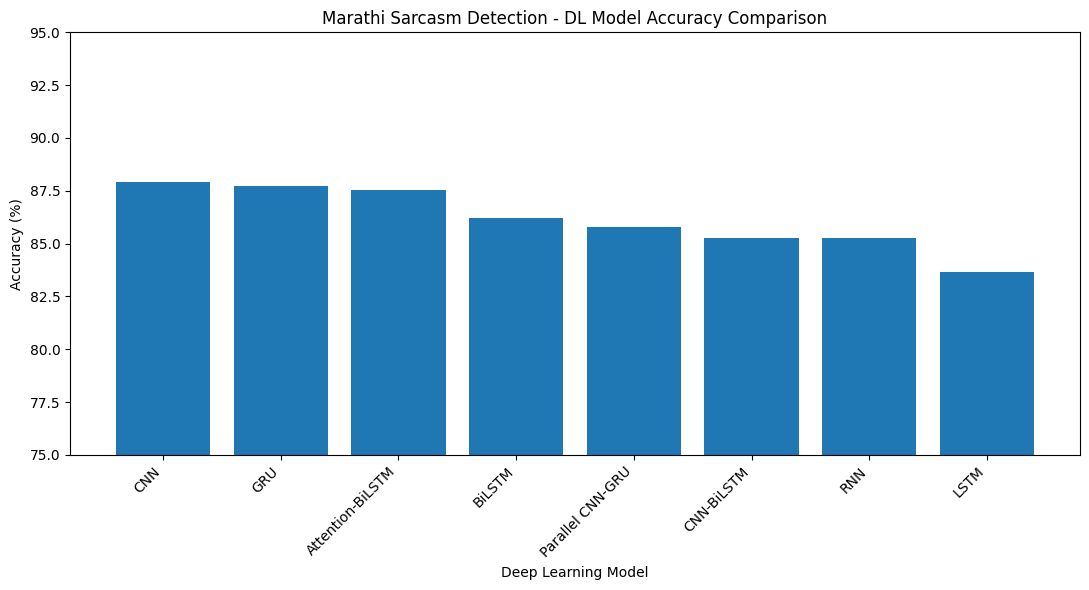

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

plt.bar(
    dl_results_df['Model'],
    dl_results_df['Accuracy'] * 100
)

plt.xlabel('Deep Learning Model')
plt.ylabel('Accuracy (%)')
plt.title('Marathi Sarcasm Detection - DL Model Accuracy Comparison')

plt.xticks(rotation=45, ha='right')
plt.ylim(75, 95)

plt.tight_layout()

plt.savefig(
    'sarcasm_dl_accuracy_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

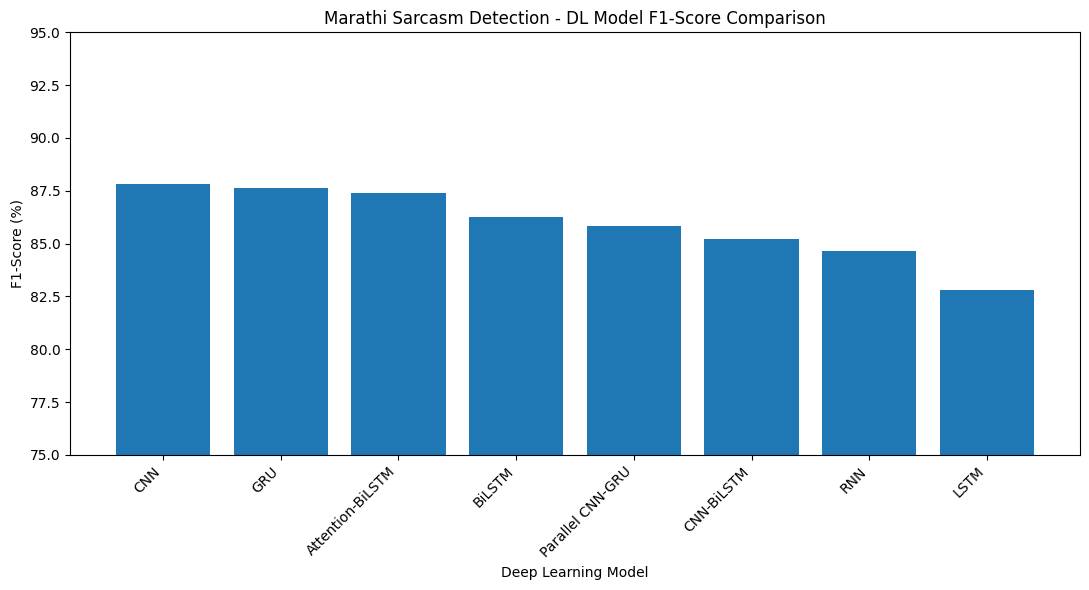

In [62]:
plt.figure(figsize=(11, 6))

plt.bar(
    dl_results_df['Model'],
    dl_results_df['F1-Score'] * 100
)

plt.xlabel('Deep Learning Model')
plt.ylabel('F1-Score (%)')
plt.title('Marathi Sarcasm Detection - DL Model F1-Score Comparison')

plt.xticks(rotation=45, ha='right')
plt.ylim(75, 95)

plt.tight_layout()

plt.savefig(
    'sarcasm_dl_f1_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

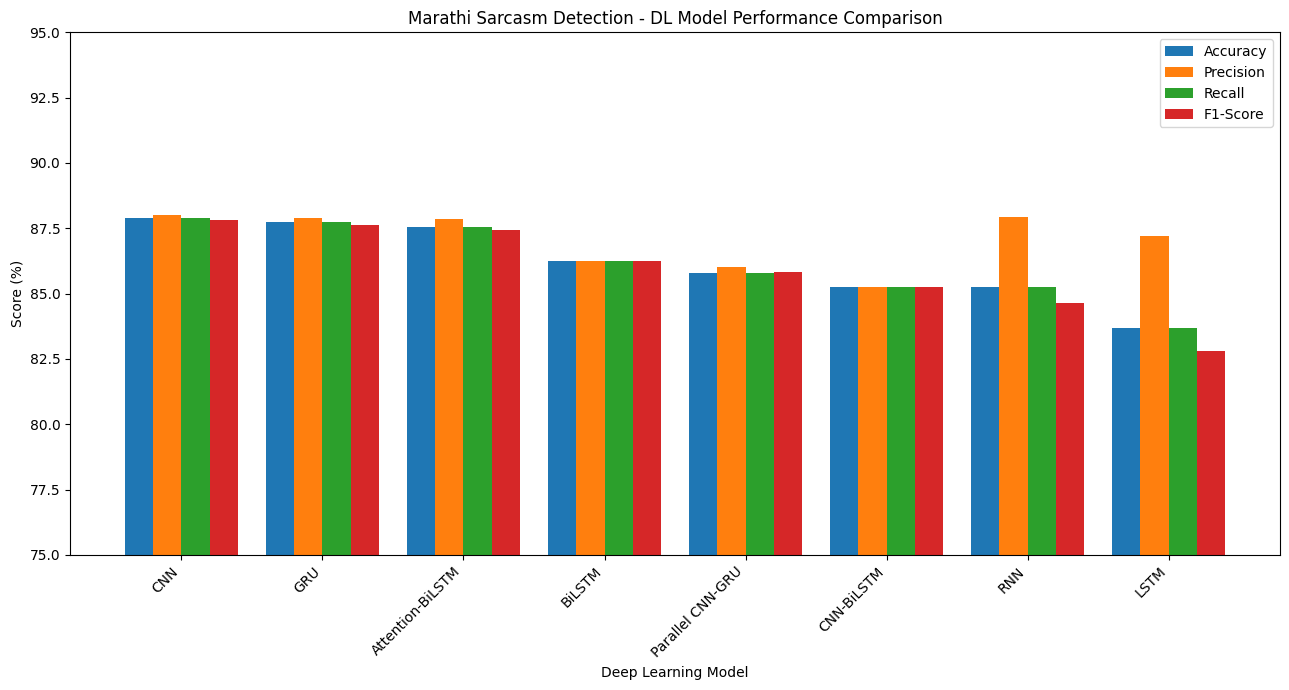

In [63]:
import numpy as np

x = np.arange(len(dl_results_df['Model']))
width = 0.2

plt.figure(figsize=(13, 7))

plt.bar(
    x - 1.5 * width,
    dl_results_df['Accuracy'] * 100,
    width,
    label='Accuracy'
)

plt.bar(
    x - 0.5 * width,
    dl_results_df['Precision'] * 100,
    width,
    label='Precision'
)

plt.bar(
    x + 0.5 * width,
    dl_results_df['Recall'] * 100,
    width,
    label='Recall'
)

plt.bar(
    x + 1.5 * width,
    dl_results_df['F1-Score'] * 100,
    width,
    label='F1-Score'
)

plt.xlabel('Deep Learning Model')
plt.ylabel('Score (%)')
plt.title('Marathi Sarcasm Detection - DL Model Performance Comparison')

plt.xticks(
    x,
    dl_results_df['Model'],
    rotation=45,
    ha='right'
)

plt.ylim(75, 95)
plt.legend()

plt.tight_layout()

plt.savefig(
    'sarcasm_dl_all_metrics_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [64]:
# Step 47: Save best Sarcasm DL model

import joblib

# Save CNN model
cnn_model.save('sarcasm_cnn.keras')

# Save tokenizer
joblib.dump(
    tokenizer,
    'sarcasm_dl_tokenizer.pkl'
)

# Save label encoder
joblib.dump(
    label_encoder,
    'sarcasm_dl_label_encoder.pkl'
)

print("Best Sarcasm DL model saved successfully!")

Best Sarcasm DL model saved successfully!


In [66]:
from google.colab import files

files_to_download = [
    'sarcasm_dl_model_comparison.csv',
    'sarcasm_dl_accuracy_comparison.png',
    'sarcasm_dl_f1_comparison.png',
    'sarcasm_dl_all_metrics_comparison.png',
    'sarcasm_cnn.keras',
    'sarcasm_dl_tokenizer.pkl',
    'sarcasm_dl_label_encoder.pkl'
]

for file in files_to_download:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>